# 04 — Sentiment surprise (Workstream 4)

Redesign of the July 2026 surprise pilot (**NO-GO** on that sample).

**What changes vs July**
- FNSPID wide panel (thousands of date clusters, not ~28).
- Trailing fitted market model for post-news `ar_mm_h1`, open(t)→open(t+1)
  (window 120, gap 21).
- Firm trailing baseline **and** cross-sectional daily mean removed.
- Sector layer off (no sector table).
- Primary statistic: **evaluation OOS R²** (loss vs development-mean
  benchmark). Clustered coefficient t-stats are secondary.

**July reference (explicit):** level OOS R² +0.003411 vs surprise −0.005515.

**Level signal:** `mean_continuous` from the aggregation panel.
**Control:** the immediately preceding open-to-open return ending at event
session t (`ret_lag1`) in every model. It does not overlap the forward outcome.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from repo root or final_experiments/")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_PRICE_ZIP,
    FROZEN_DEV_END,
    FROZEN_EVAL_START,
)
from final_experiments.lib.surprise import (  # noqa: E402
    BASELINE_MODEL,
    JULY_PILOT_NOTE,
    SurpriseConfig,
    build_surprise_panel,
    decomposition_summary,
    nested_oos_horse_race,
    oos_r2_comparison,
)

try:
    from IPython.display import display
except ImportError:  # pragma: no cover

    def display(obj: object) -> None:
        print(obj)


plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "04_surprise"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
print("aggregators:", AGG_PATH)
print("prices:", DEFAULT_PRICE_ZIP)
print("output:", OUTPUT_DIR)
print(JULY_PILOT_NOTE)

aggregators: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet
prices: /Users/peterprendergast/Documents/Sentiment_Dissertation_data/FNSPID/bf9189c41527198897d1af3e17b1a0095279fc45/raw/Stock_price/full_history.zip
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/04_surprise
July 2026 surprise pilot NO-GO: level beat surprise on OOS R² (+0.003411 vs -0.005515); only ~28 evaluation date clusters; raw market difference; no cross-sectional demeaning.


## 0. Build demeaning stack + market-model AR

In [2]:
panel = pd.read_parquet(AGG_PATH)
panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
cfg = SurpriseConfig(level_col="mean_continuous")
surprise, build_meta = build_surprise_panel(panel, price_zip=DEFAULT_PRICE_ZIP, config=cfg)
print(
    f"rows={len(surprise):,}  with AR={build_meta['n_with_market_model_ar']:,}  "
    f"missing prices={build_meta['missing_price_symbols'][:10]}"
)
display(pd.Series(build_meta["config"], name="config").to_frame())

surprise.to_parquet(OUTPUT_DIR / "firm_day_surprise.parquet", index=False)

rows=715,546  with AR=695,076  missing prices=[]


,config
level_col,mean_continuous
outcome_col,ar_mm_h1
firm_baseline_news_days,20
firm_baseline_min_periods,5
market_window,120
market_gap,21
market_min_obs,80
use_firm_baseline,True
use_cross_section,True
use_sector,False


## 1. Date-cluster gate

If evaluation clusters are not much larger than 28, stop. Ten times the
failed pilot = 280.

In [3]:
dev = surprise.loc[surprise["split"] == "development"]
ev = surprise.loc[surprise["split"] == "evaluation"]
cluster_table = pd.DataFrame(
    [
        {
            "split": "development",
            "firm_days": len(dev),
            "date_clusters": dev["session_date"].nunique(),
            "symbols": dev["symbol"].nunique(),
        },
        {
            "split": "evaluation",
            "firm_days": len(ev),
            "date_clusters": ev["session_date"].nunique(),
            "symbols": ev["symbol"].nunique(),
        },
    ]
)
display(cluster_table)
assert int(cluster_table.loc[cluster_table["split"] == "evaluation", "date_clusters"].iloc[0]) >= 280
print("Evaluation date-cluster gate PASSED (≥ 280).")

,split,firm_days,date_clusters,symbols
0,development,512153,2264,570
1,evaluation,203393,998,570


Evaluation date-cluster gate PASSED (≥ 280).


## 2. Decomposition: baseline vs market-wide vs idiosyncratic

,component,mean,mean_abs,share_of_abs_sum
0,firm_baseline,0.0791,0.1217,0.3188
1,market_wide_cs,0.0005,0.0379,0.1225
2,idiosyncratic,0.0000,0.2999,0.5587


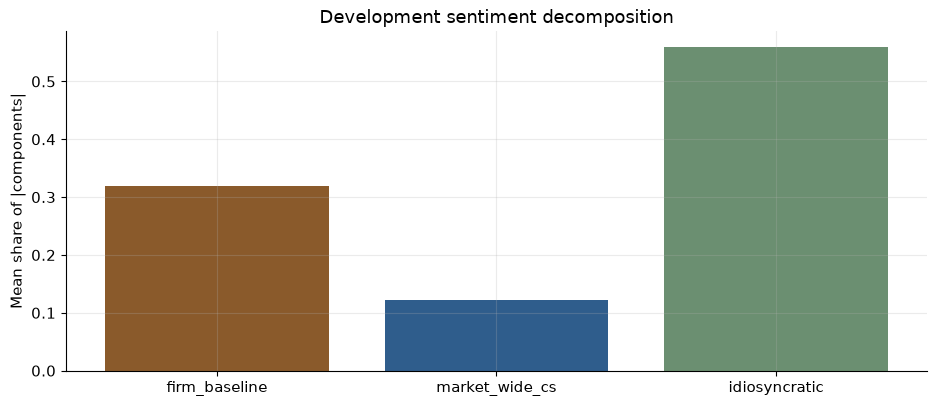

In [4]:
decomp = decomposition_summary(surprise.loc[surprise["split"] == "development"])
display(decomp.round(4))
decomp.to_csv(OUTPUT_DIR / "decomposition_development.csv", index=False)

fig, ax = plt.subplots()
ax.bar(decomp["component"], decomp["share_of_abs_sum"], color=["#8a5a2b", "#2f5d8c", "#6b8f71"])
ax.set_ylabel("Mean share of |components|")
ax.set_title("Development sentiment decomposition")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "decomposition_development.png", dpi=140)
plt.show()

## 3. Nested OOS horse race

Fit on development, predict evaluation. Models: level, surprise, both,
firm-only surprise. Every model includes `ret_lag1`.

,model,oos_r2,predictors,evaluation_date_clusters
12,M_firm_only,0.000158,ret_lag1|surprise_firm,998
5,M_surprise,0.000119,ret_lag1|surprise_full,998
0,M_control_only,0.000065,ret_lag1,998
2,M_level,0.000035,ret_lag1|level,998
8,M_both,0.000013,ret_lag1|level|surprise_full,998


{'n_development': 491681,
 'n_evaluation': 203382,
 'development_date_clusters': 2123,
 'evaluation_date_clusters': 998,
 'outcome': 'ar_mm_h1',
 'july_pilot_note': 'July 2026 surprise pilot NO-GO: level beat surprise on OOS R² (+0.003411 vs -0.005515); only ~28 evaluation date clusters; raw market difference; no cross-sectional demeaning.',
 'min_eval_clusters_gate': 280,
 'eval_clusters_pass': True,
 'model_oos_r2': [{'model': 'M_firm_only',
   'oos_r2': 0.00015795967503440256,
   'evaluation_date_clusters': 998,
   'predictors': 'ret_lag1|surprise_firm'},
  {'model': 'M_surprise',
   'oos_r2': 0.0001192087744739112,
   'evaluation_date_clusters': 998,
   'predictors': 'ret_lag1|surprise_full'},
  {'model': 'M_control_only',
   'oos_r2': 6.531590314884372e-05,
   'evaluation_date_clusters': 998,
   'predictors': 'ret_lag1'},
  {'model': 'M_level',
   'oos_r2': 3.542895128916257e-05,
   'evaluation_date_clusters': 998,
   'predictors': 'ret_lag1|level'},
  {'model': 'M_both',
   'oos_

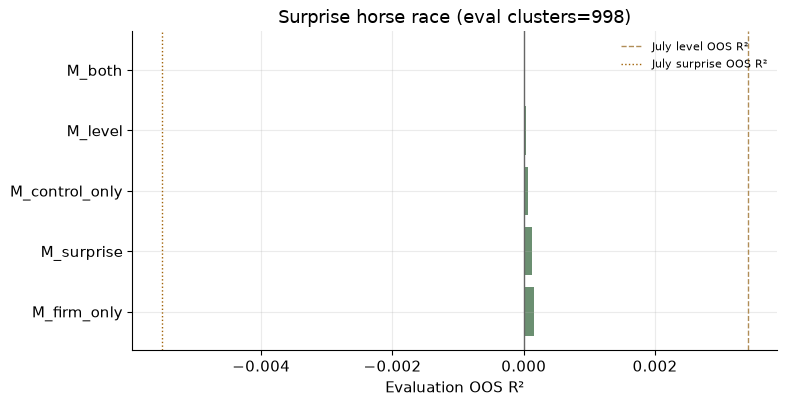

Best model: M_firm_only  OOS R²=0.000158
Control only (ret_lag1):        +0.000065
M_level                         +0.000035   Δ vs control -0.000030   Δ vs level +0.000000
M_firm_only                     +0.000158   Δ vs control +0.000093   Δ vs level +0.000123
M_surprise                      +0.000119   Δ vs control +0.000054   Δ vs level +0.000084
M_both                          +0.000013   Δ vs control -0.000052   Δ vs level -0.000022

Primary read: fully demeaned surprise beats level on OOS R².


In [5]:
race, race_meta = nested_oos_horse_race(surprise, outcome_col="ar_mm_h1")
model_oos = (
    race.drop_duplicates("model")[["model", "oos_r2", "predictors", "evaluation_date_clusters"]]
    .sort_values("oos_r2", ascending=False)
)
display(model_oos.round(6))
display(race_meta)
race.to_csv(OUTPUT_DIR / "oos_horse_race_coefficients.csv", index=False)
model_oos.to_csv(OUTPUT_DIR / "oos_horse_race_models.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.2))
plot = model_oos.set_index("model")
colors = ["#6b8f71" if v > 0 else "#8c3d3d" for v in plot["oos_r2"]]
ax.barh(plot.index, plot["oos_r2"], color=colors)
ax.axvline(0.0, color="#666", lw=1)
ax.axvline(0.003411, color="#b08d57", ls="--", lw=1, label="July level OOS R²")
ax.axvline(-0.005515, color="#a16207", ls=":", lw=1, label="July surprise OOS R²")
ax.set_xlabel("Evaluation OOS R²")
ax.set_title(
    f"Surprise horse race (eval clusters={race_meta['evaluation_date_clusters']})"
)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "oos_r2_horse_race.png", dpi=140)
plt.show()

best = model_oos.iloc[0]
r2 = model_oos.set_index("model")["oos_r2"].astype(float)
print(f"Best model: {best['model']}  OOS R²={best['oos_r2']:.6f}")
print(f"Control only (ret_lag1):        {r2['M_control_only']:+.6f}")
for name in ("M_level", "M_firm_only", "M_surprise", "M_both"):
    print(
        f"{name:<32}{r2[name]:+.6f}   "
        f"Δ vs control {r2[name] - r2['M_control_only']:+.6f}   "
        f"Δ vs level {r2[name] - r2['M_level']:+.6f}"
    )

# "Surprise" is not one thing. surprise_firm peels only the firm's own trailing
# level; surprise_full additionally peels the daily cross-sectional mean. They
# can and do land on opposite sides of the level benchmark, so reporting a single
# surprise-vs-level verdict would hide the actual result.
print()
if r2["M_firm_only"] > r2["M_level"] and r2["M_surprise"] <= r2["M_level"]:
    print(
        "Primary read: firm-baseline surprise BEATS level; adding the cross-sectional\n"
        "peel gives the gain back. The demeaning layer that matters is the firm's own\n"
        "trailing sentiment, not the market-wide daily mean."
    )
elif r2["M_surprise"] > r2["M_level"]:
    print("Primary read: fully demeaned surprise beats level on OOS R².")
else:
    print("Primary read: no surprise variant beats level (aligned with July NO-GO direction).")

## 3b. Is the ranking bigger than the noise?

Date-block bootstrap (blocks of 5 consecutive evaluation sessions, 999 reps)
on the OOS R² **differential** against the control-only nest. Every model is
rescored on the same resampled sessions, so this is a paired loss comparison,
not four independent intervals.

,model,oos_r2,delta_vs_baseline,delta_ci_low,delta_ci_high,delta_p_two_sided,bh_reject_q05,evaluation_sessions
0,M_firm_only,0.000158,0.000093,0.000040,0.000175,0.001001,True,998
1,M_surprise,0.000119,0.000054,0.000023,0.000098,0.002002,True,998
2,M_control_only,0.000065,0.000000,0.000000,0.000000,NaN,False,998
3,M_level,0.000035,-0.000030,-0.000071,0.000001,0.062062,False,998
4,M_both,0.000013,-0.000052,-0.000797,0.000559,0.848849,False,998


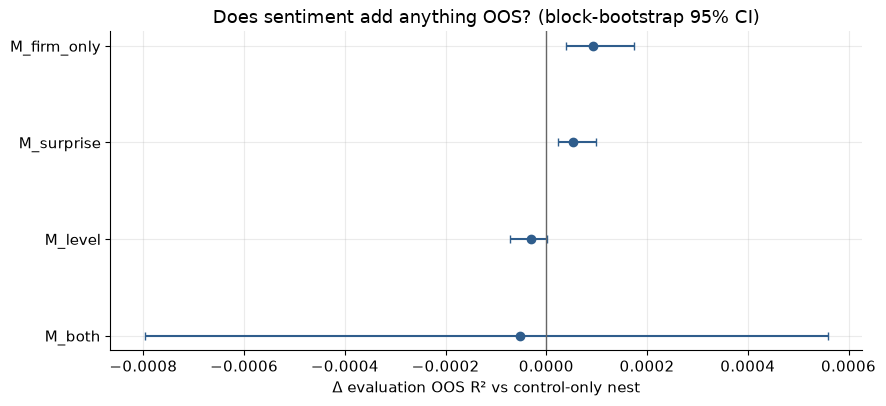

Models surviving BH q=0.05 across the four sentiment additions: M_surprise, M_firm_only


In [6]:
cmp_table = oos_r2_comparison(
    surprise,
    outcome_col="ar_mm_h1",
    baseline_model=BASELINE_MODEL,
    block_length=5,
    replications=999,
    seed=20260731,
)
sentiment_family = cmp_table["model"] != BASELINE_MODEL
cmp_table["bh_reject_q05"] = False
cmp_table.loc[sentiment_family, "bh_reject_q05"] = benjamini_hochberg(
    cmp_table.loc[sentiment_family, "delta_p_two_sided"].fillna(1.0).tolist(), q=0.05
)
cmp_table["multiplicity_family"] = "four sentiment model additions vs control-only nest"
display(
    cmp_table[
        [
            "model",
            "oos_r2",
            "delta_vs_baseline",
            "delta_ci_low",
            "delta_ci_high",
            "delta_p_two_sided",
            "bh_reject_q05",
            "evaluation_sessions",
        ]
    ].round(6)
)
cmp_table.to_csv(OUTPUT_DIR / "oos_r2_bootstrap_vs_control.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.2))
plot_cmp = cmp_table.loc[cmp_table["model"] != BASELINE_MODEL].sort_values("delta_vs_baseline")
ax.errorbar(
    plot_cmp["delta_vs_baseline"],
    range(len(plot_cmp)),
    xerr=[
        plot_cmp["delta_vs_baseline"] - plot_cmp["delta_ci_low"],
        plot_cmp["delta_ci_high"] - plot_cmp["delta_vs_baseline"],
    ],
    fmt="o",
    color="#2f5d8c",
    capsize=3,
)
ax.axvline(0.0, color="#666", lw=1)
ax.set_yticks(range(len(plot_cmp)))
ax.set_yticklabels(plot_cmp["model"])
ax.set_xlabel("Δ evaluation OOS R² vs control-only nest")
ax.set_title("Does sentiment add anything OOS? (block-bootstrap 95% CI)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "oos_r2_delta_vs_control.png", dpi=140)
plt.show()

sig = plot_cmp.loc[plot_cmp["bh_reject_q05"], "model"].tolist()
print(
    "Models surviving BH q=0.05 across the four sentiment additions: "
    + (", ".join(sig) if sig else "none")
)

## 4. Coefficient table (secondary)

Date-clustered SEs on the **evaluation** block for the best model and for
M_both. Not the primary decision statistic.

In [7]:
for model in ("M_both", "M_level", "M_surprise"):
    sub = race.loc[race["model"] == model, ["term", "coefficient", "std_error", "t_stat", "p_value", "oos_r2"]]
    print(f"\n=== {model} ===")
    display(sub.round(4))


=== M_both ===


,term,coefficient,std_error,t_stat,p_value,oos_r2
8,const,0.0001,0.0004,0.1390,0.8895,0.0
9,ret_lag1,-0.0155,0.0177,-0.8759,0.3811,0.0
10,level,-0.0005,0.0026,-0.1805,0.8568,0.0
11,surprise_full,0.0014,0.0025,0.5862,0.5577,0.0



=== M_level ===


,term,coefficient,std_error,t_stat,p_value,oos_r2
2,const,-0.0000,0.0003,-0.1605,0.8725,0.0
3,ret_lag1,-0.0158,0.0178,-0.8899,0.3735,0.0
4,level,0.0009,0.0004,2.0635,0.0391,0.0



=== M_surprise ===


,term,coefficient,std_error,t_stat,p_value,oos_r2
5,const,0.0000,0.0003,0.0797,0.9365,0.0001
6,ret_lag1,-0.0157,0.0178,-0.8786,0.3796,0.0001
7,surprise_full,0.0010,0.0003,3.9762,0.0001,0.0001


In [8]:
manifest = {
    "notebook": "04_surprise",
    "built_for": "Workstream 4 sentiment surprise redesign",
    "primary_spine": "FNSPID",
    "level_signal": cfg.level_col,
    "outcome": "ar_mm_h1",
    "outcome_timing": "event_session_open_t_to_next_exchange_session_open_t_plus_1",
    "initial_reaction_control": "ret_lag1_is_prior_exchange_open_to_event_open",
    "market_model": {
        "window": cfg.market_window,
        "gap": cfg.market_gap,
        "min_obs": cfg.market_min_obs,
    },
    "frozen_split": {
        "development_end": FROZEN_DEV_END,
        "evaluation_start": FROZEN_EVAL_START,
    },
    "july_pilot_note": JULY_PILOT_NOTE,
    "build_meta": build_meta,
    "race_meta": race_meta,
    "model_oos_r2": model_oos.to_dict(orient="records"),
    "primary_statistic": "evaluation_oos_r2_vs_control_only_nest",
    "baseline_model": BASELINE_MODEL,
    "oos_r2_bootstrap": cmp_table.to_dict(orient="records"),
    "multiplicity_family": "four sentiment model additions vs control-only nest",
    "fdr": "benjamini_hochberg_q_0.05",
    "sector_layer": "inactive",
    "analysis_status": "exploratory_repaired_2026-07-31",
    "supersedes": "outputs/superseded/20260731_pre_rigour_repair/04_surprise",
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str) + "\n")
print(json.dumps({k: manifest[k] for k in ("outcome", "primary_statistic", "july_pilot_note")}, indent=2))

{
  "outcome": "ar_mm_h1",
  "primary_statistic": "evaluation_oos_r2_vs_control_only_nest",
  "july_pilot_note": "July 2026 surprise pilot NO-GO: level beat surprise on OOS R\u00b2 (+0.003411 vs -0.005515); only ~28 evaluation date clusters; raw market difference; no cross-sectional demeaning."
}


### Carry-forward

1. Primary call is the OOS R² ordering **against the control-only nest**, with
   the block-bootstrap differential CI and eval cluster count disclosed.
2. July NO-GO remains the prior; this run is a redesign, not a silent retry.
   Report the split verdict: firm-baseline surprise vs fully demeaned surprise
   behave differently, and collapsing them into one "surprise" claim is wrong.
3. Sector demeaning stays blocked until a sector table exists.
4. Interpretation and Gate F1 evidence: `05_interpretation`.
5. Next listed workstream: story-type conditioning (`06_story_type`).